# Klasteryzacja

**Zadanie 1.**

Proszę zaimportować zbiór danych iris.

In [1]:
from sklearn.datasets import load_iris
import pandas as pd

iris = load_iris()

X = pd.DataFrame(iris.data, columns=iris.feature_names)

y = iris.target

target_names = iris.target_names


**Zadanie 2.**

Proszę wyświetlić dane i zwizualizować wszystkie pary zmiennych.

In [2]:
X.head()

,sepal length (cm),sepal width (cm),petal length (cm),petal width (cm)
0,5.1,3.5,1.4,0.2
1,4.9,3.0,1.4,0.2
2,4.7,3.2,1.3,0.2
3,4.6,3.1,1.5,0.2
4,5.0,3.6,1.4,0.2


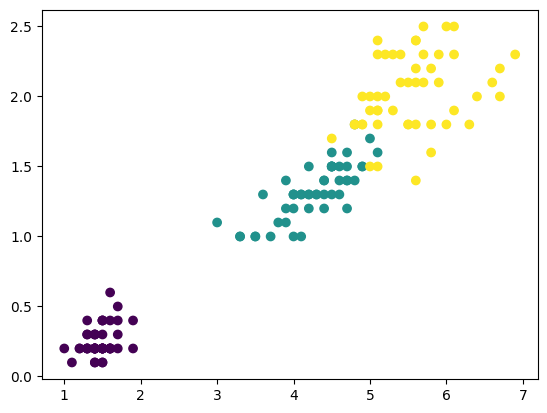

In [3]:
import matplotlib.pyplot as plt
# 1
plt.scatter(X['petal length (cm)'], X['petal width (cm)'], c = y)
plt.show()

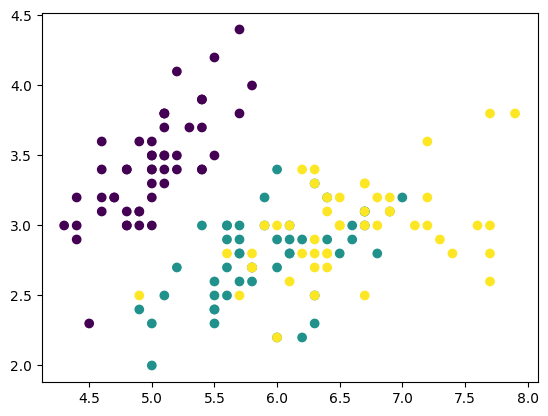

In [4]:
# 2
plt.scatter(X['sepal length (cm)'], X['sepal width (cm)'], c = y)
plt.show()

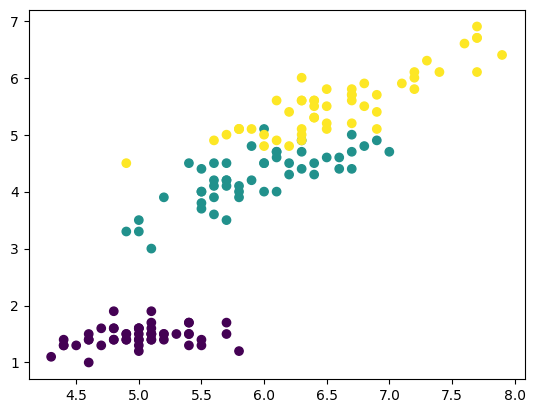

In [5]:
# 3
plt.scatter(X['sepal length (cm)'], X['petal length (cm)'], c = y)
plt.show()

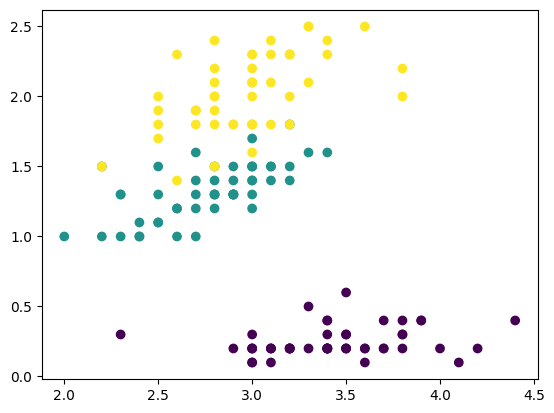

In [6]:
# 4
plt.scatter(X['sepal width (cm)'], X['petal width (cm)'], c = y)
plt.show()

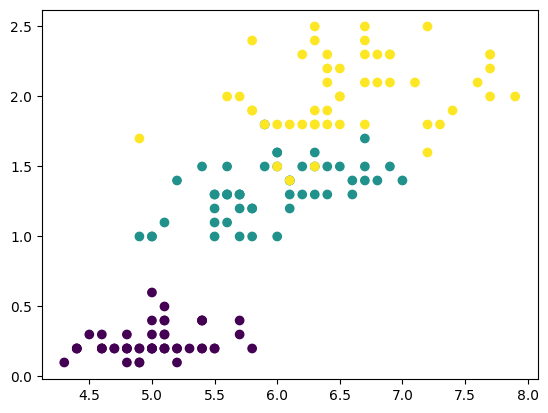

In [7]:
# 5
plt.scatter(X['sepal length (cm)'], X['petal width (cm)'], c = y)
plt.show()

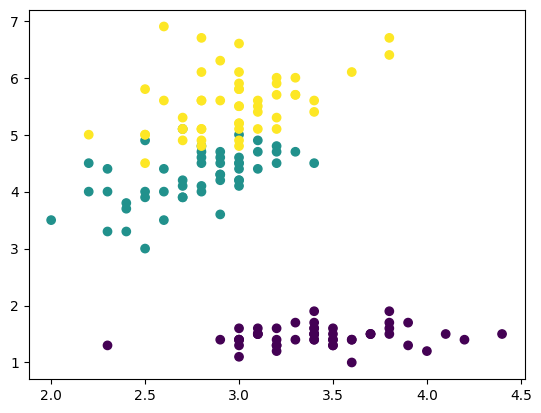

In [8]:
# 6
plt.scatter(X['sepal width (cm)'], X['petal length (cm)'], c = y)
plt.show()

**Zadanie 3.**

Proszę opisać co oznaczają zmienne.

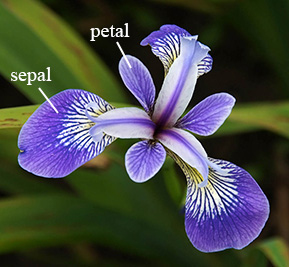

Źródło: https://www.math.umd.edu/~petersd/666/html/iris_pca.html

**Zadanie 4.**

Proszę wykonać klasteryzację za pomocą algorytmu k-średnich dla pewnej liczby klastrów.

In [9]:
from sklearn.cluster import KMeans

kmeans = KMeans(n_clusters = 6, random_state = 2025)
kmeans.fit_predict(X)

kmeans.inertia_

39.30610712530712

**Zadanie 5.**

Proszę zbadać ile klastrów powinno być w danych. Warto rozważyć takie metryki jak suma kwadratów odległości do centroidów, indeks Silhouette'a, indeks Daviesa-Bouldina czy indeks Calinskiego-Harabasza.

In [11]:
from sklearn.metrics import silhouette_score, davies_bouldin_score, calinski_harabasz_score
import numpy as np

ch = []
db = []
silhouette = []
inertias = []
for i in range(2,10):
  kmeans = KMeans(n_clusters=i, random_state = 2025)
  labels = kmeans.fit_predict(X)
  inertias.append(kmeans.inertia_)
  silhouette.append(silhouette_score(X, labels))
  db.append(davies_bouldin_score(X, labels))
  ch.append(calinski_harabasz_score(X, labels))


m1 = np.array(inertias)
m2 = np.array(silhouette)
m3 = np.array(db)
m4 = np.array(ch)

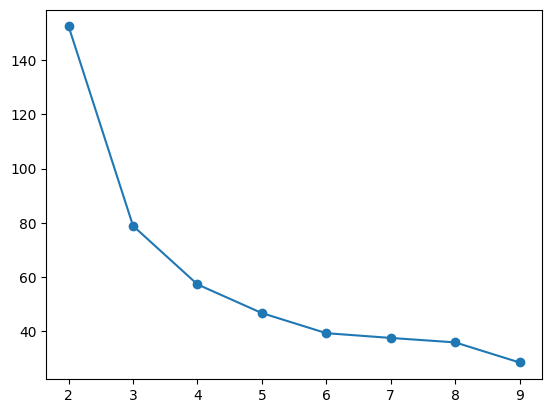

In [13]:
plt.plot(list(range(2,10)), m1, marker="o")
plt.show()

In [14]:
# Intertia -> im mniej tym lepiej
# Silhouette -> im bliżej 1 tym lepiej, wartości w (-1,1)
# Davies-Bouldin -> im mniej tym lepiej
# Calinski-Harabasz -> im więcej tym lepiej

s_m1 = m1/m1[0]
s_m2 = np.abs(1-m2)
s_m3 = (m3 - np.min(m3))/(np.max(m3) - np.min(m3))
s_m4 = 1-(m4 - np.min(m4))/(np.max(m4) - np.min(m4))

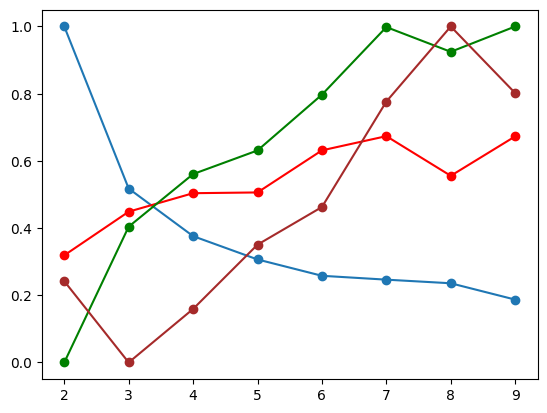

In [15]:
import numpy as np

plt.plot(range(2, 10), s_m1, marker="o")
plt.plot(range(2, 10), s_m2, marker="o", color = 'red')
plt.plot(range(2, 10), s_m3, marker="o", color = 'green')
plt.plot(range(2, 10), s_m4, marker="o", color = 'brown')
plt.show()

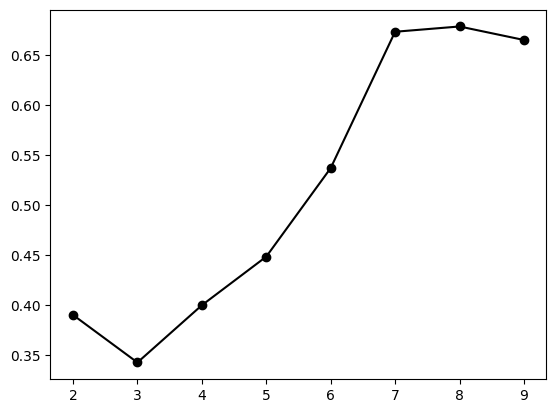

In [16]:
agg = (s_m1 + s_m2 + s_m3 + s_m4)/4

plt.plot(range(2, 10), agg, marker="o", color = 'black')
plt.show()

**UWAGA!**

Zastosowano tutaj różne standaryzacje, różnych metryk, a następnie ich agregację. Proszę przeanalizować zalety i wady takiego rozwiązania.

**Zadanie 6.**

Proszę podzielić dane na wybraną w zadaniu piątym liczbę klastrów, a następnie za pomocą metryk klasyfikacji ocenić czy klasteryzacja była skuteczna.

In [17]:
kmeans = KMeans(n_clusters=3, random_state=2025)
pred_labels = kmeans.fit_predict(X)
true_labels = y

# Proszę wyjaśnić dlaczego dokonano poniższego przekształcenia.
pred_labels = 2*pred_labels
pred_labels[pred_labels == 4] = pred_labels[pred_labels == 4]/4

In [18]:
from sklearn.metrics import (
    confusion_matrix,
    accuracy_score,
    precision_score,
    f1_score,
    classification_report,
)

labs = np.unique(np.concatenate([true_labels, pred_labels]))

cm = confusion_matrix(true_labels, pred_labels, labels=labs)

acc = accuracy_score(true_labels, pred_labels)

precision_macro = precision_score(true_labels, pred_labels, average="macro", zero_division=0)

f1_macro = f1_score(true_labels, pred_labels, average="macro", zero_division=0)

specificity_per_class = {}
for i, cls in enumerate(labs):
    TP = cm[i, i]
    FN = cm[i, :].sum() - TP
    FP = cm[:, i].sum() - TP
    TN = cm.sum() - (TP + FN + FP)
    spec = TN / (TN + FP) if (TN + FP) > 0 else np.nan
    specificity_per_class[cls] = spec

specificity_macro = np.nanmean(list(specificity_per_class.values()))

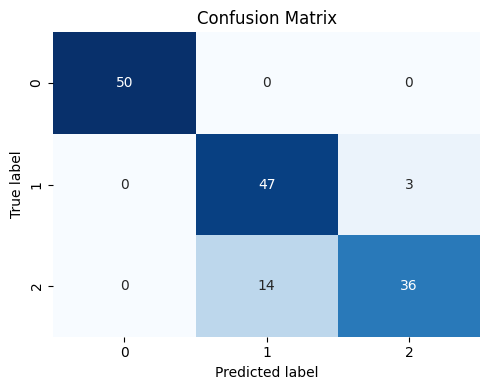

In [19]:
import seaborn as sns

plt.figure(figsize=(5, 4))
sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    cmap="Blues",
    cbar=False
)
plt.xlabel("Predicted label")
plt.ylabel("True label")
plt.title("Confusion Matrix")
plt.tight_layout()
plt.show()


In [20]:
acc

0.8866666666666667

In [21]:
precision_macro

0.8978562421185372

In [22]:
f1_macro

0.8852785369639302

In [23]:
specificity_macro

np.float64(0.9433333333333334)

**Zadanie 7.**

Proszę zwizualizować porównanie etykiet

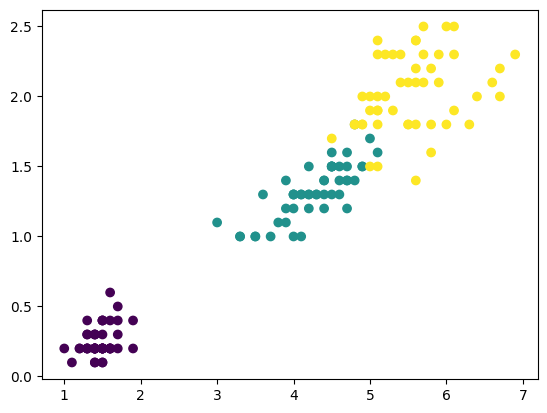

In [24]:
plt.scatter(X['petal length (cm)'], X['petal width (cm)'], c = true_labels)
plt.show()

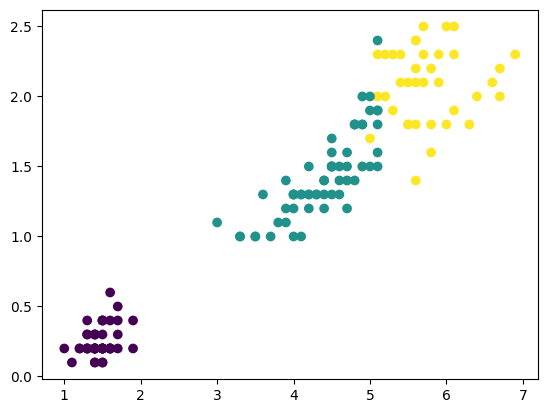

In [25]:
plt.scatter(X['petal length (cm)'], X['petal width (cm)'], c = pred_labels)
plt.show()

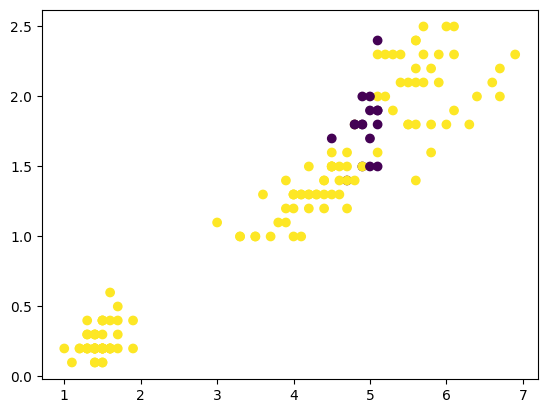

In [26]:
plt.scatter(X['petal length (cm)'], X['petal width (cm)'], c = pred_labels == true_labels)
plt.show()

**Zadanie 8.**

Proszę wyjaśnić dlaczego nie można sprawdzić jakości klasteryzacji metodami ROC i AUC, nawet gdy tak jak tutaj prawdziwe etykiety są dostępne.

Do obliczenia ROC i AUC niezbędne jest prawdopodobieństwo przynależności do danej klasy. W przypadku klasteryzacji nie ma informacji o prawdopodobieństwie przynależności do danego klastra.